# Сортировка мусора

Детекция пластиковых бутылок и других объектов на ленте конвейере

In [301]:
# !pip install ultralytics
# !pip install torchmetrics[detection]
# !pip install albumentations
# !pip install faster-coco-eval

In [4]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patheffects import withStroke

from sklearn.model_selection import train_test_split

import cv2
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision.transforms import v2
from torchvision import models, datasets
from torchvision.ops import box_convert

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchmetrics.detection.iou import IntersectionOverUnion
from torchinfo import summary

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [2]:
class Ansi:
    green = '\033[32m'
    red = '\033[31m'
    bold = '\033[1m'
    underline = '\033[4m'
    end = '\033[0m'

In [5]:
class UnNormalize(v2.Normalize):
    def __init__(self,mean, std, *args, **kwargs):
        new_mean = [-m/s for m, s in zip(mean, std)]
        new_std = [1/s for s in std]
        super().__init__(new_mean, new_std, *args, **kwargs)

unnorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

In [6]:
def _bbox_and_label(ax, boxes, labels, text_align='left', box_color='white'):
    for box, label in zip(boxes, labels):
        # Координаты рамки
        x_min, y_min, x_max, y_max = box

        # Добавить рамку
        rect = patches.Rectangle(
            (x_min, y_min),  # Левый верхний угол
            x_max - x_min,   # Ширина
            y_max - y_min,   # Высота
            linewidth=.7,
            edgecolor=box_color,
            facecolor='none',
        )
        ax.add_patch(rect)

        # В зависимости от text_align определяем положение текста отосительно рамски
        match text_align:
            case 'left':
                test_params = dict(
                    x=x_min + 3,
                    y=y_min + 3,
                    horizontalalignment='left',
                )
            case 'right':
                test_params = dict(
                    x=x_max - 3,
                    y=y_min + 3,
                    horizontalalignment='right',
                )

        # Добавить подпись
        txt = ax.text(
            **test_params,
            s=label,
            color=box_color,
            fontsize=10,
            # fontweight='bold',
            backgroundcolor=box_color,
            verticalalignment='top',
            bbox=dict(facecolor=box_color, pad=3, alpha=.3, edgecolor=box_color),
        )
        # Обводка текста
        txt.set_path_effects([
            withStroke(linewidth=3, foreground='black')
        ])


def draw_bounding_boxes(sample_set, predict=None, test_mode=False):
    if not test_mode:
        img_name, img, target = sample_set
        boxes = target['boxes'].tolist()
        labels = target['labels'].tolist()
    else:
        img_name, img = sample_set

    img = unnorm(img).numpy().transpose((1, 2, 0))

    fig, ax = plt.subplots(1, figsize=(9, 9))
    ax.set_title(img_name)
    ax.imshow(img)

    if not test_mode:
        _bbox_and_label(ax, boxes, labels, text_align='left', box_color='#32fc00')

    if predict is not None:
        pred_boxes = predict['boxes'].tolist()
        pred_labels = predict['labels'].tolist()
        pred_scores = predict['scores'].tolist()
        _bbox_and_label(ax, pred_boxes, pred_labels, text_align='right', box_color='#fc1d00')

    ax.axis('off')
    plt.show()

In [115]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

EPOCHS = 20
BATCH_SIZE = 4

PATH = Path('../../Documents/datasets/waste_detection')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch use: {Ansi.green}{Ansi.bold}{DEVICE}{Ansi.end}', 
      f'({torch.cuda.get_device_name()})' 
      if torch.cuda.is_available() else '')

torch use: cuda (AMD Radeon RX 7800 XT)


## Load data

In [8]:
train_data = pd.read_csv(PATH.joinpath('train.csv'))
test_data = pd.read_csv(PATH.joinpath('test.csv'))

sample_submission = pd.read_csv(PATH.joinpath('sample_submission.csv'))

img_path = PATH.joinpath('images')

In [9]:
train_data.head()

,file_name,bbox,category_id
0,000001.jpg,"[840.0, 0.0, 176.0, 124.0]",4.0
1,000001.jpg,"[612.0, 306.0, 383.0, 397.0]",2.0
2,000001.jpg,"[990.92, 551.0, 105.00000000000011, 186.0]",4.0
3,000002.jpg,"[1000.0, 614.0, 98.0, 178.0]",4.0
4,000002.jpg,"[605.0, 358.0, 402.0, 409.0]",2.0


In [10]:
test_data.head()

,file_name
0,000003.jpg
1,000006.jpg
2,000013.jpg
3,000016.jpg
4,000019.jpg


In [11]:
sample_submission.head()

,file_name,bbox
0,000003.jpg,"[[5.0, 0.64, 536.1, 76.56, 834.52, 890.82], [5..."
1,000006.jpg,"[[4.0, 0.91, 397.68, 3.2, 218.05, 970.42], [4...."
2,000013.jpg,[]
3,000016.jpg,"[[8.0, 0.89, 587.89, 771.75, 636.26, 337.43], ..."
4,000019.jpg,"[[7.0, 0.68, 75.08, 220.41, 982.22, 794.76], [..."


In [12]:
idx_to_class = {
    1: 'PET (transparent) (green)',
    2: 'PET (transparent) (brown)',
    3: 'PET (transparent) (blue)',
    4: 'PET (transparent)',
    5: 'PET (transparent) (dark blue)',
    6: 'PET (black)',
    7: 'PET (white)',
    8: 'PET (sticker)',
    9: 'PET (flacon)',
    10: 'PET (household chemicals)',
    11: 'PND (household chemicals)',
    12: 'PND packet',
    13: 'Other plastic',
    14: 'Other plastic (transparent)',
    15: 'Not plastic'
}

In [13]:
annotations = {}

for _, row in train_data.iterrows():
    file_name = row['file_name']
    category_id = row['category_id']

    if file_name not in annotations:
        annotations[file_name] = {'boxes': [], 'labels': []}
    if not np.isnan(category_id):
        # Преобразуем строку в список
        bbox = ast.literal_eval(row['bbox'])
        # [x_left, y_top, width, height] --> [x_min, y_min, x_max, y_max]
        bbox[2] = bbox[2] + bbox[0]
        bbox[3] = bbox[3] + bbox[1]
        annotations[file_name]['boxes'].append(bbox)
        annotations[file_name]['labels'].append(int(category_id))


img_names = list(annotations.keys())

In [14]:
train_img, val_img = train_test_split(img_names, test_size=.2, random_state=SEED)

test_img = test_data['file_name'].tolist()

In [110]:
class CustomDataset(Dataset):
    def __init__(self, path, img_names, annotations=None, transform=None):
        self.path = path
        self.img_names = img_names
        self.annotations = annotations
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img = Image.open(self.path.joinpath(img_name)).convert('RGB')
        img = np.array(img)

        boxes = self.annotations[img_name]['boxes']
        labels = self.annotations[img_name]['labels']

        if self.transform is not None:
            transformed = self.transform(
                image=img,
                bboxes=boxes,
                class_labels=labels,
            )
            img = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['class_labels']
        
        target = {
            # При отсутствии аннотаций reshape(-1, 4) 
            # автоматически создаёт пустой тензор правильной формы.
            'boxes': torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }

        return img_name, img, target


class CustomDatasetTest(CustomDataset):
    
    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img = Image.open(self.path.joinpath(img_name)).convert('RGB')
        img = np.array(img)

        if self.transform is not None:
            transformed = self.transform(image=img)
            img = transformed['image']

        return img_name, img

In [111]:
MAX_SIZE = 512

train_transform = A.Compose([
    A.LongestMaxSize(max_size=MAX_SIZE),  # Изменение размера по длинной стороне
    # A.PadIfNeeded(min_height=MAX_SIZE, min_width=MAX_SIZE, border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0)),
    # A.PadIfNeeded(min_height=MAX_SIZE, min_width=MAX_SIZE, border_mode=cv2.BORDER_REFLECT), # Дополнить до нужного размера
    A.HorizontalFlip(.5),
    A.RandomBrightnessContrast(p=.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))


val_transform = A.Compose([
    A.LongestMaxSize(max_size=MAX_SIZE),
    # A.PadIfNeeded(min_height=MAX_SIZE, min_width=MAX_SIZE, border_mode=cv2.BORDER_CONSTANT, value=(0, 0, 0)),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))


test_transform = A.Compose([
    A.LongestMaxSize(max_size=MAX_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


train_set = CustomDataset(img_path, train_img, annotations, transform=train_transform)
val_set = CustomDataset(img_path, val_img, annotations, transform=val_transform)
test_set = CustomDatasetTest(img_path, test_img, transform=test_transform)

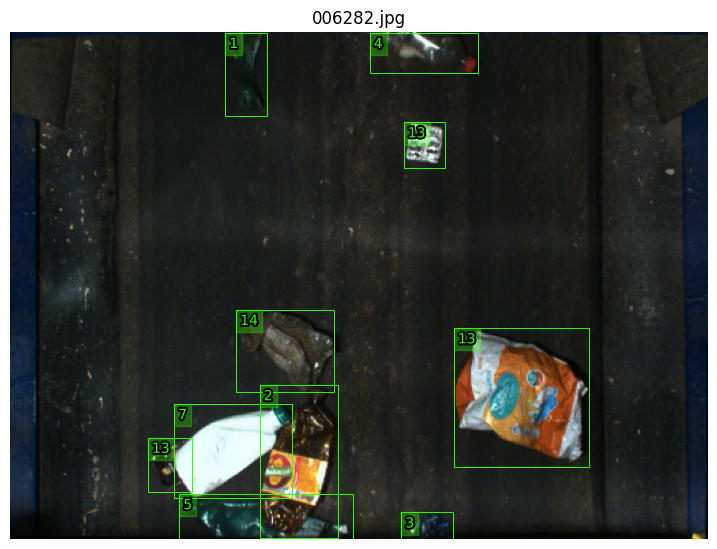

In [100]:
random_idx = np.random.choice(len(train_set))

draw_bounding_boxes(train_set[random_idx])

In [130]:
original_height, original_width = np.array(Image.open(img_path.joinpath(img_names[0]))).shape[:2]
scaled_height, scaled_width = train_set[0][1].shape[1:]

In [112]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
# model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
#     weights='FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1'
# ).to(DEVICE)


# model.load_state_dict(torch.load('best_model.pt'))

In [95]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [140]:
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(
    weights='FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1',
)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, len(idx_to_class) + 1)

model = model.to(DEVICE)

model.load_state_dict(torch.load('best_model_fasterrcnn_mobilenet_v3_large_fpn.pt'))

/tmp/ipykernel_78335/216282348.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_fasterrcnn_mobilenet_v3_large_fpn.pt'))


<All keys matched successfully>

In [137]:
params = [p for p in model.parameters() if p.requires_grad]
# optimizer = optim.SGD(params, lr=3e-4, momentum=.9, weight_decay=.0005)
optimizer = optim.AdamW(params, lr=3.6e-5) #6e-4
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=.87)

metric_map = MeanAveragePrecision(iou_type='bbox').to(DEVICE)
metric_map.warn_on_many_detections = False
metric_iou = IntersectionOverUnion().to(DEVICE)

# eval_log = pd.DataFrame()
# best_map = .7

In [138]:
def batch_preprocess(images, targets):
    images = list(image.to(DEVICE) for image in images)
    targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
    return images, targets

In [ ]:
for epoch in range(EPOCHS):
    train_loss = []
    last_lr = scheduler.get_last_lr()[0]

    # TRAIN
    model.train()
    loop = tqdm(train_loader, leave=False)
    for _, images, targets in loop:
        images, targets = batch_preprocess(images, targets)

        optimizer.zero_grad()
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        loss.backward()
        optimizer.step()

        train_loss.append(loss.detach().item())
        loop_description = f'Epoch [{epoch + 1}/{EPOCHS}], lr: {last_lr:.1e} loss: {np.mean(train_loss):.4f}'
        loop.set_description(loop_description)

    # VALID
    # Сбрасываем метрику перед валидацией
    metric_map.reset()
    metric_iou.reset()
    model.eval()
    with torch.no_grad():
        loop = tqdm(val_loader, desc='evaluation', leave=False)
        for _, images, targets in loop:
            images, targets = batch_preprocess(images, targets)
            outputs = model(images)
    
            # Подсчёт метрик
            metric_map.update(outputs, targets)
            metric_iou.update(outputs, targets)

    # Вычисление итоговой метрики
    val_iou = metric_iou.compute()['iou'].item()
    val_map = metric_map.compute()['map'].item()

    # Вывод результатов обучения для эпохи
    print(
        loop_description, 
        f"| IoU: {val_iou:.4f}, "
        f"mAP: {Ansi.bold}{val_map:.4f}{Ansi.end}",
        end = ' '
    )

    # Scheduler step
    scheduler.step()

    # Save best model
    if best_map < val_map:
        best_map = val_map
        torch.save(model.state_dict(), 'best_model_.pt')
        print(f'{Ansi.bold}{Ansi.green}save model{Ansi.end}')

    # Log
    eval_log.loc[epoch+1, 'lr'] = last_lr
    eval_log.loc[epoch+1, 'train_loss'] = np.mean(train_loss)
    eval_log.loc[epoch+1, 'val_iou'] = val_iou
    eval_log.loc[epoch+1, 'val_map'] = val_map

Epoch [6/20], lr: 1.8e-05 loss: 0.2184 | IoU: 0.4670, mAP: 0.7873 save model

## draw validation

In [70]:
def get_predict(model, sample_set):
    model.eval()
    with torch.no_grad():
        image = sample_set[1]
        image = [image.to(DEVICE)]
        outputs = model(image)[0]

    return {k: v.cpu() for k, v in outputs.items()}

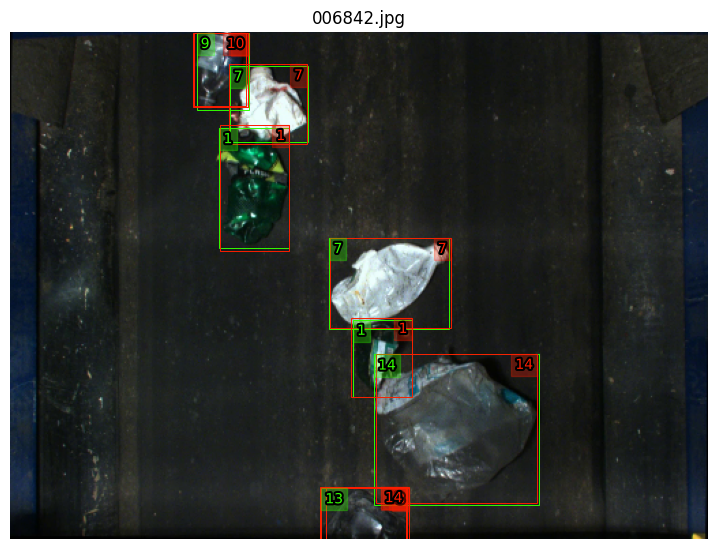

In [141]:
img_name = np.random.choice(val_img)
idx_val_set = val_img.index(img_name)

sample_set = val_set[idx_val_set]

predict = get_predict(model, sample_set)
draw_bounding_boxes(sample_set, predict)

## draw test

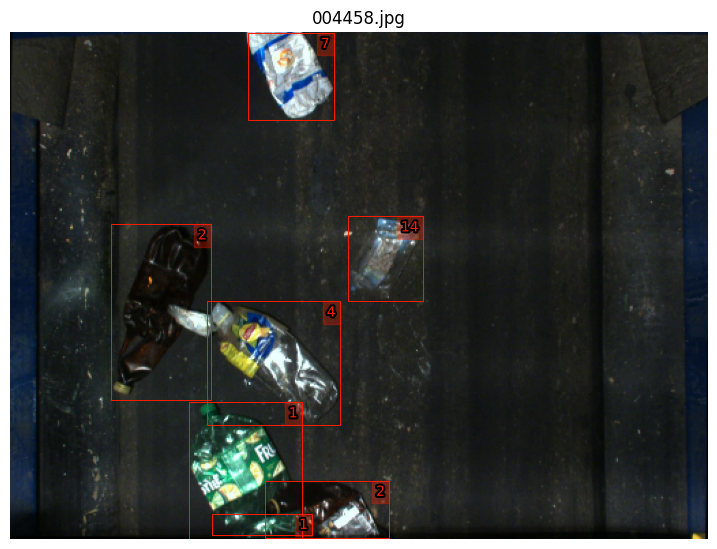

In [142]:
random_idx = np.random.choice(len(test_set))

sample_set = test_set[random_idx]

predict = get_predict(model, sample_set)
draw_bounding_boxes(sample_set, predict, test_mode=True)

## submission

In [143]:
predictions = []

model.eval()
with torch.no_grad():
    for _, images in tqdm(test_loader): 
        images = list(image.to(DEVICE) for image in images)

        # Предсказания модели
        outputs = model(images)
        outputs = [{k: v.cpu().tolist() for k, v in o.items()} for o in outputs]
        predictions.extend(outputs)

  0%|          | 0/750 [00:00<?, ?it/s]

In [144]:
submission = pd.DataFrame()

for i, (img_name, predict) in enumerate(zip(test_img, predictions)):
    bbox = []

    for box, label, score in zip(*predict.values()):
        x_min, y_min, x_max, y_max = box
        
        x_min = x_min * (original_width / scaled_width)
        x_max = x_max * (original_width / scaled_width)
        y_min = y_min * (original_height / scaled_height)
        y_max = y_max * (original_height / scaled_height)
        
        width = x_max - x_min
        height = y_max - y_min
        bbox.append([label, score, x_min, y_min, width, height])

    submission.loc[i, 'file_name'] = img_name
    submission.loc[i, 'bbox'] = str(bbox)

submission.to_csv('submission.csv', index=False)
print(f'{Ansi.green}Submission file created{Ansi.end}')

Submission file created


In [145]:
sample_submission

,file_name,bbox
0,000003.jpg,"[[5.0, 0.64, 536.1, 76.56, 834.52, 890.82], [5..."
1,000006.jpg,"[[4.0, 0.91, 397.68, 3.2, 218.05, 970.42], [4...."
2,000013.jpg,[]
3,000016.jpg,"[[8.0, 0.89, 587.89, 771.75, 636.26, 337.43], ..."
4,000019.jpg,"[[7.0, 0.68, 75.08, 220.41, 982.22, 794.76], [..."
...,...,...
2994,008986.jpg,"[[7.0, 0.1, 402.9, 964.16, 652.63, 273.57], [7..."
2995,008989.jpg,"[[4.0, 0.22, 12.38, 247.02, 954.12, 720.33], [..."
2996,008991.jpg,"[[7.0, 0.37, 954.55, 592.88, 619.44, 212.06], ..."
2997,008995.jpg,"[[14.0, 0.83, 185.66, 38.81, 170.07, 87.41], [..."


In [146]:
submission

,file_name,bbox
0,000003.jpg,"[[2, 0.999975323677063, 612.2484130859375, 428..."
1,000006.jpg,"[[2, 0.9999819993972778, 613.8672485351562, 60..."
2,000013.jpg,"[[2, 0.9999886751174927, 613.8268432617188, 10..."
3,000016.jpg,"[[10, 0.9999926090240479, 694.0823364257812, 7..."
4,000019.jpg,"[[4, 0.9999790191650391, 903.523681640625, 654..."
...,...,...
2994,008986.jpg,"[[4, 0.9999985694885254, 1566.701171875, 1148...."
2995,008989.jpg,"[[4, 0.9999544620513916, 1565.328125, 1326.935..."
2996,008991.jpg,"[[2, 0.9999716281890869, 883.3345947265625, 72..."
2997,008995.jpg,"[[1, 0.9999854564666748, 321.07318115234375, 3..."
